In [1]:
import pandas as pd
import numpy as np
data=pd.read_csv(r"C:\Users\k.navadeepreddy\Downloads\apple_stock (1).csv")
data

,Unnamed: 0,Adj Close,Close,High,Low,Open,Volume
0,1980-12-12,0.098834,0.128348,0.128906,0.128348,0.128348,469033600
1,1980-12-15,0.093678,0.121652,0.122210,0.121652,0.122210,175884800
2,1980-12-16,0.086802,0.112723,0.113281,0.112723,0.113281,105728000
3,1980-12-17,0.088951,0.115513,0.116071,0.115513,0.115513,86441600
4,1980-12-18,0.091530,0.118862,0.119420,0.118862,0.118862,73449600
...,...,...,...,...,...,...,...
11102,2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300
11103,2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500
11104,2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700
11105,2025-01-02,243.850006,243.850006,249.100006,241.820007,248.929993,55558000


In [2]:
data.columns=['Date','Adj Close','Close','High','Low','Open','Volume']

In [3]:
data['Date']=pd.to_datetime(data['Date'])

In [4]:
data=data[['Close']]

In [5]:
from sklearn.preprocessing import MinMaxScaler
mmc=MinMaxScaler(feature_range=(0,1))
scaled_data=mmc.fit_transform(data)

In [6]:
time_steps=60

In [32]:
import tensorflow
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
time_series_generator=TimeseriesGenerator(scaled_data,scaled_data,length=time_steps,batch_size=64)

In [33]:
train_size=int(len(scaled_data)*0.8)
train_data=scaled_data[:train_size]
test_data=scaled_data[train_size:]

In [34]:
train_data_series_generator=TimeseriesGenerator(train_data,train_data,length=time_steps,batch_size=64)
test_data_series_generator=TimeseriesGenerator(test_data,test_data,length=time_steps,batch_size=64)

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM
model=Sequential()
model.add(LSTM(units=40,activation='relu',input_shape=(time_steps,1)))
model.add(Dense(units=1))

C:\Users\k.navadeepreddy\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(train_data_series_generator,epochs=35,validation_data=test_data_series_generator)

Epoch 1/35


C:\Users\k.navadeepreddy\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 4.6506e-04 - val_loss: 76492.1641
Epoch 2/35
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0626e-05 - val_loss: 16684023.0000
Epoch 3/35
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1986e-06 - val_loss: 187265600.0000
Epoch 4/35
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1577e-06 - val_loss: 1159182.6250
Epoch 5/35
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.5532e-06 - val_loss: 50145.0703
Epoch 6/35
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.1390e-06 - val_loss: 890199.1875
Epoch 7/35
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7407e-06 - val_loss: 44671.4258
Epoch 8/35
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.4774e-06 - val_loss: 6407.6880
Epoch 9/35
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.6368e-05 - val_loss: 1289.4449
Epoch 10/35
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0677e-06 - val_loss: 654.9076
Epoch 11/35
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step 

In [37]:
predictions=model.predict(test_data_series_generator)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [38]:
predictions=mmc.inverse_transform(predictions)
actual_prices=mmc.inverse_transform(test_data[time_steps:])

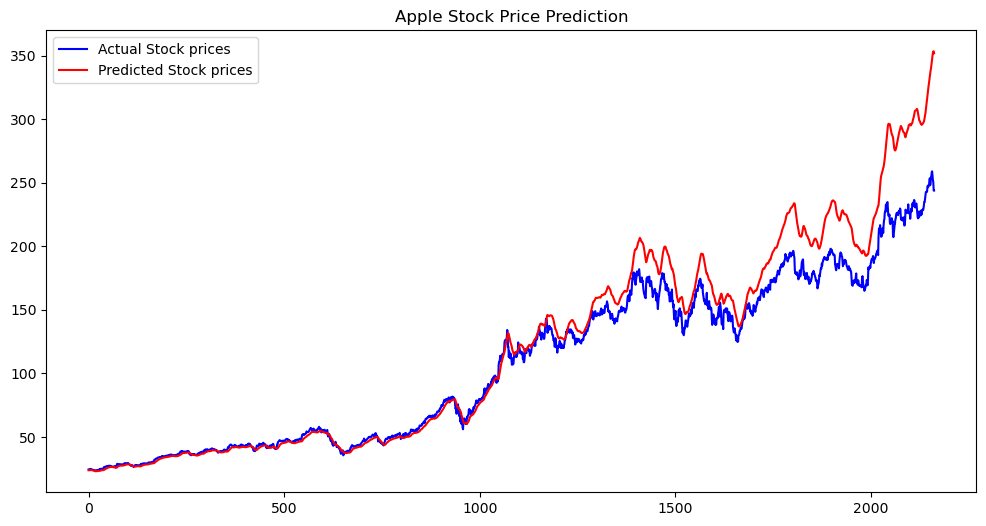

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(actual_prices,color='blue',label='Actual Stock prices')
plt.plot(predictions,color='red',label='Predicted Stock prices')
plt.title('Apple Stock Price Prediction')
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import r2_score,mean_squared_error
score=r2_score(predictions,actual_prices)
mse=mean_squared_error(predictions,actual_prices)
rmse=np.sqrt(mean_squared_error(predictions,actual_prices))
print('Accuracy : ',score)
print('Mean Squared Error : ',mse)
print('RMSE : ',rmse)

Accuracy :  0.9315522082443803
Mean Squared Error :  204.39191400016614
RMSE :  14.296570008228063
